<a href="https://colab.research.google.com/github/elinsyn/Fluid_mechanics/blob/main/Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# About the code

In [91]:
# Copyright (C) 2019 Johan Hoffman (jhoffman@kth.se)

# Setup environment

In [92]:
# Load neccessary modules.
from google.colab import files

import numpy as np
import time

# Install FEniCS (this may take a long time)
try:
    import dolfin
except ImportError:
    !wget "https://fem-on-colab.github.io/releases/fenics-install-release-real.sh" -O "/tmp/fenics-install.sh" && bash "/tmp/fenics-install.sh"
    import dolfin

from dolfin import *; from mshr import *

import dolfin.common.plotting as fenicsplot

from matplotlib import pyplot as plt

# Define domain and mesh

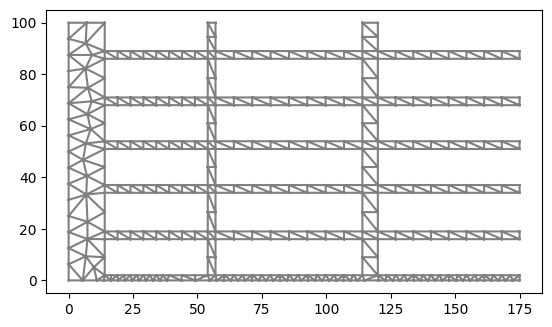

In [93]:
# Define domain
L = 175
H = 100


# Define subdomains
class Left(SubDomain):
    def inside(self, x, on_boundary):
        return near(x[0], 0.0)

class Right(SubDomain):
    def inside(self, x, on_boundary):
        return near(x[0], L)

class Lower(SubDomain):
    def inside(self, x, on_boundary):
        return near(x[1], 0.0)

class Upper(SubDomain):
    def inside(self, x, on_boundary):
        return near(x[1], H)

left = Left()
right = Right()
lower = Lower()
upper = Upper()

resolution = 16

domain = Rectangle(Point(0.0,0.0), Point(L,H))

# Manhattan
house1 = Polygon([Point(14,100),Point(14,89),Point(54,89),Point(54,100)])
house2 = Polygon([Point(14,86),Point(14,71),Point(54,71),Point(54,86)])
house3 = Polygon([Point(14,68),Point(14,54),Point(54,54),Point(54,68)])
house4 = Polygon([Point(14,51),Point(14,37),Point(54,37),Point(54,51)])
house5 = Polygon([Point(14,34),Point(14,19),Point(54,19),Point(54,34)])
house6 = Polygon([Point(14,16),Point(14,2),Point(54,2),Point(54,16)])

house7 = Polygon([Point(57,100),Point(57,89),Point(114,89),Point(114,100)])
house8 = Polygon([Point(57,86),Point(57,71),Point(114,71),Point(114,86)])
house9 = Polygon([Point(57,68),Point(57,54),Point(114,54),Point(114,68)])
house10 = Polygon([Point(57,51),Point(57,37),Point(114,37),Point(114,51)])
house11 = Polygon([Point(57,34),Point(57,19),Point(114,19),Point(114,34)])
house12 = Polygon([Point(57,16),Point(57,2),Point(114,2),Point(114,16)])

house13 = Polygon([Point(120,100),Point(120,89),Point(175,89),Point(175,100)])
house14 = Polygon([Point(120,86),Point(120,71),Point(175,71),Point(175,86)])
house15 = Polygon([Point(120,68),Point(120,54),Point(175,54),Point(175,68)])
house16 = Polygon([Point(120,51),Point(120,37),Point(175,37),Point(175,51)])
house17 = Polygon([Point(120,34),Point(120,19),Point(175,19),Point(175,34)])
house18 = Polygon([Point(120,16),Point(120,2),Point(175,2),Point(175,16)])

manhattan = generate_mesh(domain - house1- house2- house3- house4 -house5-house6 - house7- house8- house9- house10 -house11-house12- house13- house14- house15- house16 -house17-house18, resolution)

# Barcelona
casa1 = Polygon([Point(114, 84),Point(114, 67),Point(116, 63),Point(140, 63),Point(140, 88),Point(116, 88)])
casa1 = Polygon([Point(139, 100), Point(114, 100), Point(114, 96), Point(117, 94), Point(139, 93)])
casa2 = Polygon([Point(102, 100), Point(92, 100), Point(93, 94), Point(98, 94), Point(98, 97), Point(102, 97)])
casa3 = Polygon([Point(83, 100), Point(67, 100), Point(67, 97), Point(70, 94), Point(83, 94)])
casa4 = Polygon([Point(63, 100), Point(37, 100), Point(37, 97), Point(41, 94), Point(60, 94), Point(64, 97)])
casa5 = Polygon([Point(32, 100), Point(8, 100), Point(8, 99), Point(13, 97), Point(31, 97)])
casa6 = Polygon([Point(140, 87), Point(117, 87), Point(114, 85), Point(114, 67), Point(116, 63), Point(139, 63)])
casa7 = Polygon([Point(99, 87), Point(83, 88), Point(77, 64), Point(99, 63), Point(102, 66), Point(102, 84)])
casa8 = Polygon([Point(81, 89), Point(70, 89), Point(67, 86), Point(66, 68), Point(69, 65), Point(75, 65)])
casa9 = Polygon([Point(30, 91), Point(18, 91), Point(20, 66), Point(31, 66), Point(33, 69), Point(33, 87)])
casa10 = Polygon([Point(17, 91), Point(10, 91), Point(7, 89), Point(7, 69), Point(9, 67), Point(18, 66)])
casa11 = Polygon([Point(139, 59), Point(117, 59), Point(114, 57), Point(113, 37), Point(116, 35), Point(138, 35)])
casa12 = Polygon([Point(99, 60), Point(70, 60), Point(66, 57), Point(66, 39), Point(70, 35), Point(99, 35), Point(103, 38), Point(103, 56)])
casa13 = Polygon([Point(59, 61), Point(40, 61), Point(37, 58), Point(36, 40), Point(40, 37), Point(58, 36), Point(62, 39), Point(62, 57)])
casa14 = Polygon([Point(137, 25), Point(131, 25), Point(131, 22), Point(137, 22)])
casa15 = Polygon([Point(137, 19), Point(131, 18), Point(131, 15), Point(137, 15)])
casa16 = Polygon([Point(137, 12), Point(131, 12), Point(131, 8), Point(137, 8)])
casa17 = Polygon([Point(127, 29), Point(113, 28), Point(113, 23), Point(127, 23)])
casa18 = Polygon([Point(97, 31), Point(70, 32), Point(66, 29), Point(65, 17), Point(71, 18), Point(79, 21), Point(88, 22), Point(94, 25)])
casa19 = Polygon([Point(58, 32), Point(40, 33), Point(36, 29), Point(36, 15), Point(58, 15), Point(58, 21), Point(62, 21), Point(62, 28)])
casa20 = Polygon([Point(30, 33), Point(8, 33), Point(4, 30), Point(4, 12), Point(7, 9), Point(28, 9), Point(32, 12), Point(32, 29)])
casa21 = Polygon([Point(140, 3), Point(132, 3), Point(132, 0), Point(140, 0)])
casa22 = Polygon([Point(128, 4), Point(106, 4), Point(106, 0), Point(128, 0)])
casa23 = Polygon([Point(100, 4), Point(66, 4), Point(66, 0), Point(103, 0)])
casa24 = Polygon([Point(58, 4), Point(40, 5), Point(36, 2), Point(36, 0), Point(59, 0)])
casa25 = Polygon([Point(29, 5), Point(8, 5), Point(4, 2), Point(4, 0), Point(32, 0), Point(32, 2)])
casa = casa1 + casa2 + casa3 + casa4 + casa5 + casa6 + casa7 + casa8 + casa9 + casa10 + casa11 + casa12 + casa13 + casa14 + casa15 + casa16 + casa17 + casa18 + casa19 + casa20 + casa21 + casa22 + casa23 + casa24 + casa25

barcelona = generate_mesh(Rectangle(Point(0.0,0.0), Point(L,H)) - casa, resolution)

# Gamla stan hus
hus1 = Polygon([Point(141, 100), Point(124, 100), Point(129, 93)])
hus2 = Polygon([Point(153, 100), Point(144, 100), Point(130, 91), Point(130, 90), Point(155, 97)])
hus3 = Polygon([Point(158, 94), Point(139, 89), Point(130, 88), Point(131, 85), Point(160, 87)])
hus4 = Polygon([Point(160, 85), Point(141, 83), Point(131, 83), Point(132, 80), Point(148, 81), Point(160, 82)])
hus5 = Polygon([Point(161, 81), Point(147, 79), Point(132, 77), Point(134, 71), Point(149, 73), Point(163, 76)])
hus6 = Polygon([Point(163, 73), Point(134, 69), Point(136, 62), Point(164, 65)])
hus7 = Polygon([Point(164, 63), Point(136, 60), Point(137, 56), Point(164, 59)])
hus8 = Polygon([Point(164, 57), Point(137, 54), Point(138, 51), Point(150, 52), Point(164, 51)])
hus9 = Polygon([Point(164, 49), Point(138, 49), Point(138, 43), Point(164, 43)])
hus10 = Polygon([Point(164, 41), Point(138, 41), Point(138, 37), Point(154, 37), Point(154, 35), Point(164, 34)])
hus11 = Polygon([Point(152, 35), Point(138, 35), Point(137, 32), Point(150, 32)])
hus12 = Polygon([Point(164, 32), Point(153, 32), Point(152, 30), Point(137, 30), Point(138, 20), Point(165, 23)])
hus13 = Polygon([Point(164, 21), Point(138, 17), Point(139, 8), Point(164, 12)])
hus14 = Polygon([Point(164, 10), Point(141, 6), Point(141, 0), Point(164, 0)])
hus15 = Polygon([Point(120, 100), Point(109, 100), Point(119, 88), Point(121, 74), Point(125, 75), Point(128, 84), Point(127, 92)])
hus16 = Polygon([Point(126, 70), Point(124, 68), Point(127, 61), Point(128, 53), Point(128, 41), Point(128, 29), Point(132, 10), Point(135, 10), Point(135, 32), Point(136, 41), Point(135, 54), Point(134, 63)])
hus17 = Polygon([Point(120, 69), Point(116, 68), Point(119, 51), Point(121, 32), Point(126, 32), Point(126, 50), Point(124, 61)])
hus18 = Polygon([Point(126, 30), Point(121, 29), Point(124, 14), Point(130, 10)])
hus19 = Polygon([Point(116, 55), Point(113, 58), Point(97, 36), Point(108, 27), Point(118, 32), Point(116, 55)])
hus20 = Polygon([Point(117, 28), Point(110, 26), Point(115, 21), Point(120, 23)])
hus21 = Polygon([Point(114, 67), Point(81, 62), Point(81, 59), Point(79, 56), Point(94, 37), Point(114, 63)])
hus22 = Polygon([Point(117, 86), Point(105, 81), Point(108, 69), Point(120, 71)])
hus23 = Polygon([Point(103, 79), Point(79, 75), Point(81, 65), Point(106, 69)])
hus24 = Polygon([Point(100, 90), Point(90, 88), Point(92, 84), Point(100, 85)])
hus25 = Polygon([Point(87, 90), Point(76, 85), Point(78, 77), Point(91, 80)])
hus26 = Polygon([Point(104, 100), Point(100, 99), Point(103, 94), Point(110, 98), Point(109, 100)])
hus27 = Polygon([Point(65, 96), Point(44, 85), Point(51, 75), Point(70, 84)])
hus28 = Polygon([Point(72, 79), Point(55, 71), Point(62, 62), Point(77, 69)])
hus29 = Polygon([Point(77, 55), Point(68, 49), Point(75, 38), Point(87, 27), Point(94, 35), Point(84, 45)])
hus30 = Polygon([Point(96, 33), Point(88, 23), Point(94, 18), Point(102, 27)])
hus31 = Polygon([Point(107, 25), Point(99, 14), Point(113, 4), Point(119, 8), Point(124, 4), Point(128, 8)])
hus32 = Polygon([Point(134, 7), Point(130, 7), Point(126, 0), Point(138, 1)])
hus33 = Polygon([Point(64, 100), Point(46, 100), Point(50, 96), Point(59, 97)])
hus34 = Polygon([Point(36, 100), Point(27, 100), Point(33, 83), Point(44, 90)])
hus35 = Polygon([Point(43, 83), Point(35, 79), Point(43, 64), Point(51, 70)])
hus36 = Polygon([Point(52, 68), Point(45, 61), Point(57, 46), Point(64, 51)])
hus37 = Polygon([Point(65, 49), Point(59, 44), Point(69, 35), Point(83, 22), Point(85, 24), Point(76, 33), Point(70, 41)])
hus38 = Polygon([Point(26, 98), Point(22, 97), Point(28, 81), Point(32, 82)])
hus39 = Polygon([Point(33, 78), Point(30, 77), Point(33, 69), Point(40, 58), Point(53, 42), Point(55, 45), Point(44, 59), Point(38, 69)])
hus40 = Polygon([Point(58, 42), Point(56, 39), Point(71, 25), Point(81, 18), Point(82, 20), Point(69, 31)])
hus41 = Polygon([Point(85, 18), Point(83, 17), Point(103, 0), Point(107, 0)])
hus42 = Polygon([Point(19, 98), Point(14, 96), Point(17, 84), Point(2, 81), Point(2, 77), Point(25, 80)])
hus43 = Polygon([Point(26, 77), Point(0, 72), Point(0, 62), Point(6, 59), Point(28, 70)])
hus44 = Polygon([Point(30, 69), Point(8, 57), Point(12, 53)])
hus45 = Polygon([Point(32, 66), Point(21, 59), Point(14, 51), Point(19, 47), Point(34, 63)])
hus46 = Polygon([Point(35, 61), Point(21, 45), Point(25, 41), Point(39, 56)])
hus47 = Polygon([Point(41, 53), Point(28, 39), Point(34, 34), Point(46, 46)])
hus48 = Polygon([Point(47, 44), Point(36, 33), Point(42, 27), Point(52, 39)])
hus49 = Polygon([Point(54, 36), Point(45, 24), Point(70, 4), Point(79, 16), Point(66, 26)])
hus50 = Polygon([Point(82, 14), Point(72, 2), Point(74, 0), Point(99, 0), Point(90, 8)])
hus51 = Polygon([Point(0, 58), Point(0, 39), Point(8, 31), Point(19, 42)])
hus52 = Polygon([Point(21, 40), Point(11, 29), Point(21, 21), Point(31, 31)])
hus53 = Polygon([Point(33, 30), Point(24, 19), Point(30, 13), Point(39, 25)])
hus54 = Polygon([Point(42, 23), Point(33, 11), Point(43, 2), Point(53, 13)])
hus55 = Polygon([Point(55, 12), Point(46, 0), Point(69, 0)])
hus56 = Polygon([Point(8, 28), Point(0, 20), Point(12, 9), Point(20, 17)])
hus57 = Polygon([Point(21, 15), Point(14, 7), Point(21, 1), Point(28, 10)])
hus58 = Polygon([Point(30, 7), Point(24, 0), Point(40, 0)])
hus = hus1 + hus2 + hus3 + hus4 + hus5 + hus6 + hus7 + hus8 + hus9 + hus10 + hus11 + hus12 + hus13 + hus14 + hus15 + hus16 + hus17 + hus18 + hus19 + hus20 + hus21 + hus22 + hus23 + hus24 + hus25 + hus26 + hus27 + hus28 + hus29 + hus30 + hus31 + hus32 + hus33 + hus34 + hus35 + hus36 + hus37 + hus38 + hus39 + hus40 + hus41 + hus42 + hus43 + hus44 + hus45 + hus46 + hus47 + hus48 + hus49 + hus50 + hus51 + hus52 + hus53 + hus54 + hus55 + hus56 + hus57 + hus58
gamlastan = generate_mesh(Rectangle(Point(0.0,0.0), Point(L,H)) - hus, resolution)


mesh = manhattan

# Refine mesh
no_levels = 1
for i in range(0,no_levels):
  cell_marker = MeshFunction("bool", mesh, mesh.topology().dim())
  for cell in cells(mesh):
    cell_marker[cell] = False
    p = cell.midpoint()
    if p.distance(Point(0.5, 0.5)) < 1.0:
        cell_marker[cell] = True
  mesh = refine(mesh, cell_marker)

#plot(Q.mesh())

# Define mesh functions
boundaries = MeshFunction("size_t", mesh, mesh.topology().dim()-1)
boundaries.set_all(0)
left.mark(boundaries, 1)
right.mark(boundaries, 2)
lower.mark(boundaries, 3)
upper.mark(boundaries, 4)

plot(mesh)

# Define approximation spaces

In [94]:
# Generate finite element spaces
#VE = VectorElement("CG", mesh.ufl_cell(), 1)
#QE = FiniteElement("CG", mesh.ufl_cell(), 1)
#WE = VE * QE

#W = FunctionSpace(mesh, WE)
#V = FunctionSpace(mesh, VE)
#Q = FunctionSpace(mesh, QE)

V = VectorFunctionSpace(mesh, "Lagrange", 1)
Q = FunctionSpace(mesh, "Lagrange", 1)
K = FunctionSpace(mesh, "Discontinuous Lagrange", 0)

# Define trial and test functions
#(u, p) = TrialFunctions(W)
#(v, q) = TestFunctions(W)
u = TrialFunction(V)
p = TrialFunction(Q)
v = TestFunction(V)
q = TestFunction(Q)

# Define boundary conditions

In [95]:
# Define boundary conditions
class DirichletBoundaryLower(SubDomain):
    def inside(self, x, on_boundary):
        #return bool(x[1] < DOLFIN_EPS and on_boundary)
        return on_boundary and near(x[1], 0.0)

class DirichletBoundaryUpper(SubDomain):
    def inside(self, x, on_boundary):
        #return bool(x[1] > (H - DOLFIN_EPS) and on_boundary)
        return on_boundary and near(x[1], H)

class DirichletBoundaryLeft(SubDomain):
    def inside(self, x, on_boundary):
        #return bool(x[0] < DOLFIN_EPS and on_boundary)
        return on_boundary and near(x[0], 0.0)

class DirichletBoundaryRight(SubDomain):
    def inside(self, x, on_boundary):
        #return bool(x[0] > (L - DOLFIN_EPS) and on_boundary)
        return on_boundary and near(x[0], L)

class DirichletBoundaryObjects(SubDomain):
    def inside(self, x, on_boundary):
        #return bool(x[0] > (L - DOLFIN_EPS) and on_boundary)
        return on_boundary and (not near(x[0], 0.0)) and (not near(x[0], L)) and (not near(x[1], 0.0)) and (not near(x[1], H))

dbc_lower = DirichletBoundaryLower()
dbc_upper = DirichletBoundaryUpper()
dbc_left = DirichletBoundaryLeft()
dbc_right = DirichletBoundaryRight()
dbc_objects = DirichletBoundaryObjects()

#uin = Expression('4.0*x[1]*(1-x[1])', element = V.sub(0).ufl_element())
#uin = Expression('1.0 + 1.0*fabs(sin(t))', element = V.sub(0).ufl_element(), t=0.0)
uin = Expression('Umax*(1.0 - exp(-t/tau))',Umax=1.0,tau=2.0,t=0.0,degree=1)
#uin = 1.0
#bcuin = DirichletBC(V, (uin, 0.0), dbc_left)

# Left-to-right inlet: u = (Uin, 0) on left boundary
bcu_in0 = DirichletBC(V.sub(0), uin, dbc_left)
bcu_in1 = DirichletBC(V.sub(1), Constant(0.0), dbc_left)

# Slip on upper and lower walls:
# only kill normal velocity.
# For horizontal walls, normal direction is y, so set u_y = 0 only.
bcu_upper_slip = DirichletBC(V.sub(1), Constant(0.0), dbc_upper)
bcu_lower_slip = DirichletBC(V.sub(1), Constant(0.0), dbc_lower)

#bcuw0 = DirichletBC(V, (0.0, 0.0), dbc_lower)
#bcuw1 = DirichletBC(V, (0.0, 0.0), dbc_upper)

# Outlet pressure on right boundary
pout = Constant(0.0)
bcp_out = DirichletBC(Q, pout, dbc_right)

bcu = [bcu_in0, bcu_in1, bcu_upper_slip, bcu_lower_slip]

bcp = [bcp_out]

# Define model parameters

In [96]:
# Set permeability matrix
Kinv11 = Expression('100.0*fabs(sin(2.0*pi*(x[1] - 0.1*x[0])))', element = K.ufl_element())
Kinv12 = Expression('0.0', element = K.ufl_element())
Kinv21 = Kinv12
Kinv22 = Kinv11

# Set viscosity
nu = 1.0e-2

# Set effective viscosity
nueff = 1.0e-2

# Define method parameters

In [97]:
# Define functions
u0 = Function(V)
u1 = Function(V)
p0 = Function(Q)
p1 = Function(Q)

# Set method parameters
num_nnlin_iter = 5
prec = "amg" if has_krylov_solver_preconditioner("amg") else "default"

# Time step length
dt = 0.5*mesh.hmin()

# Define measure for boundary integration
ds = Measure('ds', domain=mesh, subdomain_data=boundaries)

# Define varitional problem

In [98]:
# Define variational problems
#d1 = 1.0*mesh.hmin()
#d2 = 1.0*mesh.hmin()
#d3 = 1.0e-2*mesh.hmin()

h = CellDiameter(mesh);
u_mag = sqrt(dot(u1,u1))
d1 = 1.0/sqrt((pow(1.0/dt,2.0) + pow(u_mag/h,2.0)))
#d1 = h
#d2 = 0.0
d2 = h*u_mag

n = FacetNormal(mesh)
gamma_slip = Constant(100.0)

um = 0.5*(u + u0)
um1 = 0.5*(u1 + u0)
Fu = inner((u - u0)/dt + grad(um)*um1, v)*dx \
    - p1*div(v)*dx \
    + nueff*inner(grad(um), grad(v))*dx \
    + d1*inner((u - u0)/dt + grad(um)*um1 + grad(p1), grad(v)*um1)*dx \
    + d2*div(um)*div(v)*dx \
    + nu*(Kinv11*inner(um[0],v[0])*dx
          + Kinv12*inner(um[0],v[1])*dx
          + Kinv21*inner(um[1],v[0])*dx
          + Kinv22*inner(um[1],v[1])*dx) \
    + gamma_slip*nueff/CellDiameter(mesh)*dot(um, n)*dot(v, n)*ds(0)
au = lhs(Fu)
Lu = rhs(Fu)

Fp = d1*inner((u1 - u0)/dt + grad(um1)*um1 + grad(p), grad(q))*dx + div(um1)*q*dx
ap = lhs(Fp)
Lp = rhs(Fp)

# Assemble linear matrix
# Ap = assemble(ap)

# Set I/O variables

In [99]:
# Open files
file_u = File("results-BNS/u.pvd")
file_p = File("results-BNS/p.pvd")

# Set plot frequency
plot_time = 0
plot_freq = 10

# Time stepping algorithm

Time t = 1.25


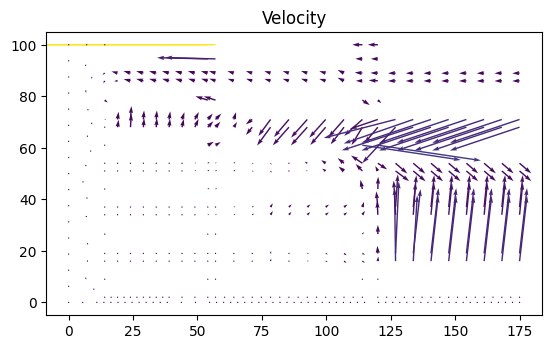

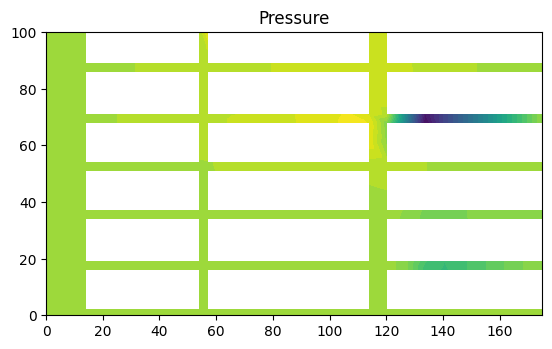

Time t = 2.5


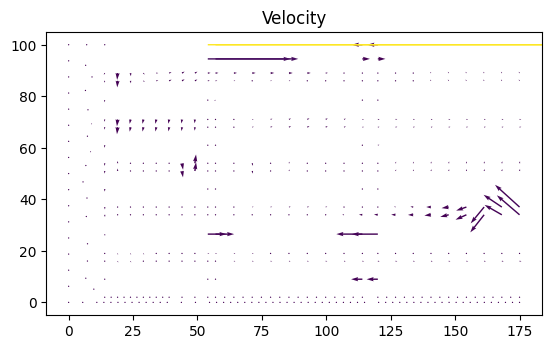

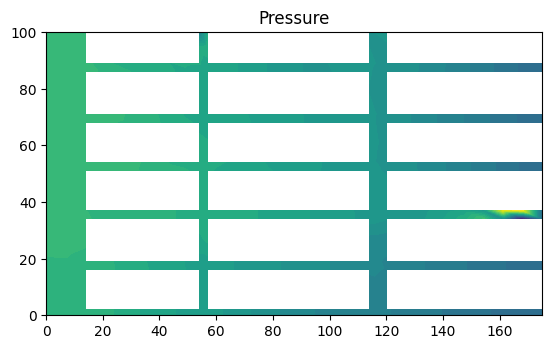

Time t = 3.75


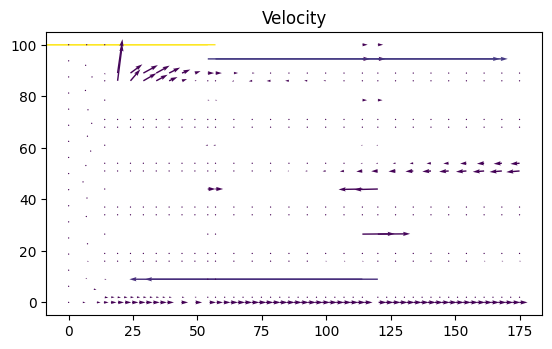

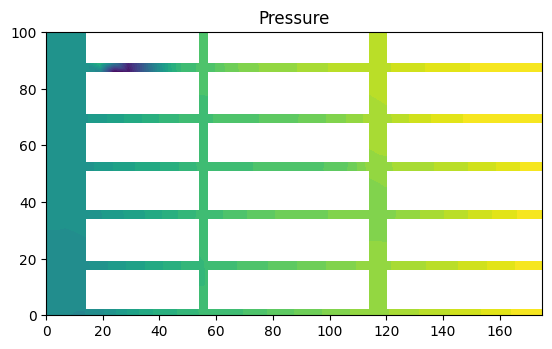

RuntimeError: 

*** -------------------------------------------------------------------------
*** DOLFIN encountered an error. If you are not able to resolve this issue
*** using the information listed below, you can ask for help at
***
***     https://fenicsproject.discourse.group/
***
*** Remember to include the error message listed below and, if possible,
*** include a *minimal* running example to reproduce the error.
***
*** -------------------------------------------------------------------------
*** Error:   Unable to solve linear system using PETSc Krylov solver.
*** Reason:  Solution failed to converge in 0 iterations (PETSc reason DIVERGED_PC_FAILED, residual norm ||r|| = 0.000000e+00).
*** Where:   This error was encountered inside PETScKrylovSolver.cpp.
*** Process: 0
*** 
*** DOLFIN version: 2019.2.0.dev0
*** Git changeset:  a8dcf753d3ab9ae19d7bedf8c634a4fe545032d2
*** -------------------------------------------------------------------------


In [100]:
!rm -f results-BNS/*

# Time stepping
T = 10
t = dt

while t < T + DOLFIN_EPS:

    # Update time-dependent inlet velocity
    uin.t = t

    # Use previous time step as initial guess
    u1.assign(u0)

    # Solve nonlinear problem
    k = 0
    while k < num_nnlin_iter:

        # Assemble velocity system
        Au = assemble(au)
        bu = assemble(Lu)

        # Apply velocity boundary conditions
        for bc in bcu:
            bc.apply(Au, bu)

        # Solve velocity problem
        #solve(Au, u1.vector(), bu, "gmres", "ilu")
        # If this still fails, try:
        solve(Au, u1.vector(), bu, "mumps")

        # Assemble pressure system
        Ap = assemble(ap)
        bp = assemble(Lp)

        # Apply pressure boundary conditions
        for bc in bcp:
            bc.apply(Ap, bp)

        # Solve pressure problem
        #solve(Ap, p1.vector(), bp, "gmres", "ilu")
        # Or:
        solve(Ap, p1.vector(), bp, "mumps")

        k += 1

    if t > plot_time:

        print("Time t =", t)

        file_u << u1
        file_p << p1

        plt.figure()
        plot(u1, title="Velocity")

        plt.figure()
        plot(p1, title="Pressure")

        plot_time += T/plot_freq
        plt.show()

    # Update previous solution
    u0.assign(u1)

    # Advance time
    t += dt

plt.show()